# **Análise comparativa de modelos** - Squad 11  
# <div align="center">**Hyozan**</div>



 - Conjunto de dados: Diabetes prediction dataset

 - Cientistas de dados:

      - Airan Rejane Conceição Dos Santos
      - João Volney Grangeiro Dos Santos
      - Juvenal Da Costa Lavres Da Conceição  
      - Natalia Ligabo Dos Santos

### **Distribuição das tarefas**

#####
* 1. Metodologia e Pré-processamento de dados - Airan Rejane
* 2. Validação de modelos - Natália Ligabô e João Volney
* 3. Modelagem e comparação - Natália Ligabô e João Volney

Apresentação do curso:
- Juvenal e Natalia Ligabô



## Instruções gerais



> Nesta tarefa, cada equipe deverá construir uma análise comparativa de modelos utilizando os conhecimentos adquiridos em aula. O trabalho será entregue em formato de notebook no Google Colab e deve conter as seguintes seções estruturadas: Metodologia, Configuração do Experimento, Resultados e Discussão.



In [1]:
!pip install pytorch_tabnet -q
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.9 MB/s eta 0:00:00


In [2]:
# @title Importação das bibliotecas

# Core data manipulation
import numpy as np
import pandas as pd

# Visualization
from matplotlib import pyplot as plt
import seaborn as sns

# Tools module
import itertools

# Markdown
from IPython.display import Markdown

# pipelines e transformadores
from sklearn.pipeline import Pipeline
from sklearn.base import TransformerMixin, BaseEstimator
from sklearn.compose import ColumnTransformer

# codificação de variáveis
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.feature_extraction.text import CountVectorizer

# normalização
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler


# modelagem
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_validate, KFold, ShuffleSplit, RandomizedSearchCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, Activation, MaxPool1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import AdaBoostClassifier
import torch
from pytorch_tabnet.tab_model import TabNetClassifier

In [3]:
# @title Leitura do conjunto de dados

df= pd.read_csv("https://raw.githubusercontent.com/atlantico-academy/datasets/refs/heads/main/diabetes.csv")

## 1. Metodologia


### 1.1 Conjunto de dados

In [4]:
display(Markdown("### Informações sobre o dataset."))
df.info()

### Informações sobre o dataset.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [5]:
display(Markdown("### Dimensões do dataset."))

print(f"Linhas: {df.shape[0]}.Colunas:{df.shape[1]}.")

### Dimensões do dataset.

Linhas: 100000.Colunas:9.


In [6]:
# Primeiras 5 linhas do conjunto de dados
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [7]:
#@title Dicionário de dados
df_dict = pd.DataFrame([
    {
        "variavel": "gender",
        "descricao": "Genero do participante (Male/Female/Other).",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "age",
        "descricao": "Idade do participante.",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
    {
        "variavel": "hypertension",
        "descricao": "Se o participante possui Hipertenssão Arterial Sistemica (1/0).",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "heart_disease",
        "descricao": "Se o participante possui alguma doença cardiaca(1/0)",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "smoking_history",
        "descricao": "Categorias: se o participante fuma, já fumou ou nunca fumou. As possiveis respostas são ('never' 'No Info' 'current' 'former' 'ever' 'not current')",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "bmi",
        "descricao": "Informa o IMC.",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
    {
        "variavel": "HbA1c_level",
        "descricao": "Informa o nivel da hemoglobina glicada.",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
    {
        "variavel": "blood_glucose_level",
        "descricao": "Informa o nivel da glicose no sangue.",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
    {
        "variavel": "diabetes",
        "descricao": "Informa se o paciente possui ou nao diabetes (1/0).",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    }
])
with pd.option_context('display.max_colwidth', None):
    display(df_dict)

,variavel,descricao,tipo,subtipo
0,gender,Genero do participante (Male/Female/Other).,qualitativa,nominal
1,age,Idade do participante.,quantitativa,contínua
2,hypertension,Se o participante possui Hipertenssão Arterial Sistemica (1/0).,qualitativa,nominal
3,heart_disease,Se o participante possui alguma doença cardiaca(1/0),qualitativa,nominal
4,smoking_history,"Categorias: se o participante fuma, já fumou ou nunca fumou. As possiveis respostas são ('never' 'No Info' 'current' 'former' 'ever' 'not current')",qualitativa,nominal
5,bmi,Informa o IMC.,quantitativa,contínua
6,HbA1c_level,Informa o nivel da hemoglobina glicada.,quantitativa,contínua
7,blood_glucose_level,Informa o nivel da glicose no sangue.,quantitativa,contínua
8,diabetes,Informa se o paciente possui ou nao diabetes (1/0).,qualitativa,nominal


In [8]:
#@title Preparando a variável BMI (IMC)
limite_imc = 50

df['bmi_processed'] = df['bmi'].clip(upper=limite_imc)

ids_analisados = [87843, 76093, 69549, 96066, 4551]
print(df.loc[ids_analisados, ['age', 'bmi', 'bmi_processed', 'diabetes']])

        age    bmi  bmi_processed  diabetes
87843   7.0  95.69           50.0         0
76093  16.0  95.22           50.0         0
69549  38.0  91.82           50.0         0
96066  80.0  88.76           50.0         0
4551   45.0  88.72           50.0         1


Optamos por aplicar o limite (capping) aos valores discrepantes contínuos (como o IMC) para evitar a exclusão de registros valiosos em um dataset de saúde. Valores extremos distorcem a fronteira de decisão de modelos sensíveis à escala, como a Regressão Logística e Redes Neurais. O capping preserva a tendência do paciente (obesidade severa, por exemplo) sem "quebrar" a matemática dos algoritmos.

In [9]:
#@title Criando a variável GME (media da glicose obtida apartir da hba1c)
df['gme'] = (df['HbA1c_level'] * 28.7) - 46.7
print(df[['HbA1c_level', 'gme']].head())

   HbA1c_level     gme
0          6.6  142.72
1          6.6  142.72
2          5.7  116.89
3          5.0   96.80
4          4.8   91.06


In [10]:
novas_variaveis = pd.DataFrame([
    {
        "variavel": "bmi_processed",
        "descricao": "IMC com limite máximo (capping) em 50.",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
    {
        "variavel": "gme",
        "descricao": "Média de glicose calculada a partir da HbA1c.",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    }
])

df_dict = pd.concat([df_dict, novas_variaveis], ignore_index=True)

In [11]:
# @title Seleção de variáveis e separação de entradas e saídas

variavel_alvo = ['diabetes']
variaveis_inuteis = (
    df_dict
    .query("tipo == 'inútil'")
    .variavel
    .to_list()
    )

variaveis_nao_usadas = variaveis_inuteis + variavel_alvo

variaveis_nominais = (
    df_dict
    .query("subtipo == 'nominal' and variavel not in @variaveis_nao_usadas" )
    .variavel
    .to_list()
    )

variaveis_ordinais = (
    df_dict
    .query("subtipo == 'ordinal' and variavel not in @variaveis_nao_usadas")
    .variavel
    .to_list()
)

variaveis_continuas = (
    df_dict
    .query("subtipo == 'contínua' and variavel not in @variaveis_nao_usadas")
    .variavel
    .to_list()
)

variaveis_discretas = (
    df_dict
    .query("subtipo == 'discreta' and variavel not in @variaveis_nao_usadas")
    .variavel
    .to_list()
)

X = df.drop(columns=variaveis_nao_usadas)
Y = df[variavel_alvo]





### 1.2 Pré-processamento dos dados

O pré-processamento foi definido de acordo com o tipo de variável, visando reduzir vieses estatísticos e consequentemente, melhorar a performance dos modelos de aprendizado de máquina.

#

#### **Variáveis quantitativas contínuas**

  * Não há valores ausentes no conjunto de dados.
  * Foram identificados outliers, principalmente na variável bmi (IMC).
  * Aplicamos a técnica de capping, limitando os valores ao percentil 99%, para conseguir reduzir o impacto dos valores extremos encontrados.
  * Para normalização aplicamos o StandartScaler.

#### **Variáveis quantitativas discretas**

  * O conjunto de dados não possui variáveis discretas explícitas.
  * Mas seguiria o mesmo protocolo de normalização aplicada as variáveis quantitativas contínuas.

#### **Variáveis qualitativas nominais**

  * Foram transformadas usando One-Hot Encoding com "pd.get_dummies".

#### **Variáveis qualitativas ordinais**

  * Não há variáveis ordinais explícitas no conjunto de dados. Porém, foi utilizado a técnica de labelEncoder, para transformação de categorias em números inteiros seguindo a ordem.

#### 1.2.1 Tratamento de dados faltantes


In [12]:
#@title Dados Faltantes
display(Markdown("### Quantidade de Valores Nulos"))
df.isnull().sum()

### Quantidade de Valores Nulos

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0
bmi_processed,0




> Não existem dados faltantes nesse conjunto de dados.



#### 1.2.2 Codificação de variáveis qualitativas


In [13]:

X_encoded = pd.get_dummies(X, columns=variaveis_nominais, drop_first=True)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in variaveis_ordinais:
    X_encoded[col] = le.fit_transform(X_encoded[col])

print(f"Shape após codificação: {X_encoded.shape}")
X_encoded.head()

Shape após codificação: (100000, 15)


,age,bmi,HbA1c_level,blood_glucose_level,bmi_processed,gme,gender_Male,gender_Other,hypertension_1,heart_disease_1,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,25.19,6.6,140,25.19,142.72,False,False,False,True,False,False,False,True,False
1,54.0,27.32,6.6,80,27.32,142.72,False,False,False,False,False,False,False,False,False
2,28.0,27.32,5.7,158,27.32,116.89,True,False,False,False,False,False,False,True,False
3,36.0,23.45,5.0,155,23.45,96.80,False,False,False,False,True,False,False,False,False
4,76.0,20.14,4.8,155,20.14,91.06,True,False,True,True,True,False,False,False,False


#### 1.2.3 Normalização das variáveis quantitativas


In [14]:
# @title Tratamento de Outliers via IQR (Capping)

X_refined = X_encoded.copy()

for col in variaveis_continuas:

    Q1 = X_refined[col].quantile(0.25)
    Q3 = X_refined[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    X_refined[col] = np.where(X_refined[col] < limite_inferior, limite_inferior, X_refined[col])
    X_refined[col] = np.where(X_refined[col] > limite_superior, limite_superior, X_refined[col])

print("Outliers tratados via IQR sobre os dados codificados.")

Outliers tratados via IQR sobre os dados codificados.


In [15]:
# @title Normalização
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols_to_scale = variaveis_continuas + variaveis_discretas


X_refined[cols_to_scale] = scaler.fit_transform(X_refined[cols_to_scale])

print("Normalização concluída com sucesso.")

Normalização concluída com sucesso.


#### 1.2.4 Tratamento de valores discrepantes


In [16]:
scaler = StandardScaler()

# Lista de colunas para normalizar
cols_to_scale = variaveis_continuas + variaveis_discretas

X_final = X_encoded.copy()
X_final[cols_to_scale] = scaler.fit_transform(X_encoded[cols_to_scale])

print("Variáveis quantitativas normalizadas com sucesso.")
X_final.head()

Variáveis quantitativas normalizadas com sucesso.


,age,bmi,HbA1c_level,blood_glucose_level,bmi_processed,gme,gender_Male,gender_Other,hypertension_1,heart_disease_1,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,1.692704,-0.321056,1.001706,0.047704,-0.323814,1.001706,False,False,False,True,False,False,False,True,False
1,0.538006,-0.000116,1.001706,-1.426210,0.006584,1.001706,False,False,False,False,False,False,False,False,False
2,-0.616691,-0.000116,0.161108,0.489878,0.006584,0.161108,True,False,False,False,False,False,False,True,False
3,-0.261399,-0.583232,-0.492690,0.416183,-0.593717,-0.492690,False,False,False,False,True,False,False,False,False
4,1.515058,-1.081970,-0.679490,0.416183,-1.107154,-0.679490,True,False,True,True,True,False,False,False,False


##2. Configuração do Experimento

Neste projeto a variável alvo é binária (diabetes), portanto o problema é de classificação, e não de regressão.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, Y, test_size=0.2, random_state=42, stratify=Y
)


sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Configuração concluída!")
print(f"Amostras de treino balanceadas: {len(X_train_res)} (Classes: {y_train_res.value_counts().to_dict()})")
print(f"Amostras de teste (originais): {len(X_test)}")

Configuração concluída!
Amostras de treino balanceadas: 146400 (Classes: {(0,): 73200, (1,): 73200})
Amostras de teste (originais): 20000


In [18]:
# Aprendizado de máquina

modelo = RandomForestClassifier(random_state=42)
modelo.fit(X_train_res, y_train_res.values.ravel())

print("Testando")

previsoes = modelo.predict(X_test)

print(previsoes)

Testando
[0 0 0 ... 0 0 0]


In [19]:
# Verificando a acurácia (porcentagem de acertos)
print(f"Acurácia: {accuracy_score(y_test, previsoes):.2%}")

# Mostrando um relatório detalhado

print("\nRelatório detalhado: \n")
print(classification_report(y_test, previsoes))

Acurácia: 95.77%

Relatório detalhado: 

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     18300
           1       0.75      0.75      0.75      1700

    accuracy                           0.96     20000
   macro avg       0.87      0.86      0.86     20000
weighted avg       0.96      0.96      0.96     20000



In [20]:
#@title Testando outra abordagem para o Randon Florest

variavel_alvo = ['diabetes']
variaveis_inuteis = df_dict.query("tipo == 'inútil'").variavel.to_list() + ['bmi', 'HbA1c_level']
variaveis_nao_usadas = variaveis_inuteis + variavel_alvo

# Recalculando as listas com o dicionário atualizado
variaveis_nominais = df_dict.query("subtipo == 'nominal' and variavel not in @variaveis_nao_usadas").variavel.to_list()
variaveis_ordinais = df_dict.query("subtipo == 'ordinal' and variavel not in @variaveis_nao_usadas").variavel.to_list()
variaveis_continuas = df_dict.query("subtipo == 'contínua' and variavel not in @variaveis_nao_usadas").variavel.to_list()
variaveis_discretas = df_dict.query("subtipo == 'discreta' and variavel not in @variaveis_nao_usadas").variavel.to_list()

X = df.drop(columns=variaveis_nao_usadas)
Y = df[variavel_alvo]

print(f"Variáveis contínuas que o modelo vai usar agora: {variaveis_continuas}")




X_encoded = pd.get_dummies(X, columns=variaveis_nominais, drop_first=True)

le = LabelEncoder()
for col in variaveis_ordinais:
    if col in X_encoded.columns:
        X_encoded[col] = le.fit_transform(X_encoded[col])


for col in variaveis_continuas:
    upper_limit = X_encoded[col].quantile(0.99)
    X_encoded[col] = np.where(X_encoded[col] > upper_limit, upper_limit, X_encoded[col])

# Normalização
scaler = StandardScaler()
cols_to_scale = variaveis_continuas + variaveis_discretas

X_final = X_encoded.copy()
X_final[cols_to_scale] = scaler.fit_transform(X_encoded[cols_to_scale])



X_train, X_test, y_train, y_test = train_test_split(
    X_final, Y, test_size=0.2, random_state=42, stratify=Y
)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)


modelo_lgbm = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
modelo_lgbm.fit(X_train_res, y_train_res.values.ravel())

print("\n--- TESTANDO O MODELO ---")
previsoes = modelo_lgbm.predict(X_test)


print(classification_report(y_test, previsoes))

Variáveis contínuas que o modelo vai usar agora: ['age', 'blood_glucose_level', 'bmi_processed', 'gme']

--- TESTANDO O MODELO ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.94      0.71      0.81      1700

    accuracy                           0.97     20000
   macro avg       0.96      0.85      0.90     20000
weighted avg       0.97      0.97      0.97     20000



In [21]:
# @title Preparação de Shape para CNN


X_train_cnn = X_train_res.values.reshape(X_train_res.shape[0], X_train_res.shape[1], 1)
X_test_cnn = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"Shape para CNN: {X_train_cnn.shape}")

Shape para CNN: (146400, 13, 1)


In [22]:
# @title Garantindo tipos numéricos para a CNN


X_train_cnn = X_train_cnn.astype('float32')
X_test_cnn = X_test_cnn.astype('float32')

y_train_res_cnn = np.array(y_train_res).astype('float32')
y_test_cnn = np.array(y_test).astype('float32')

print(f"Tipo de X: {X_train_cnn.dtype}")
print(f"Tipo de y: {y_train_res_cnn.dtype}")

Tipo de X: float32
Tipo de y: float32


In [23]:
# @title Construção e Treinamento da CNN

def build_cnn_diabetes(input_shape):
    model = Sequential([

        Conv1D(32, kernel_size=3, padding='same', input_shape=input_shape),
        BatchNormalization(),
        Activation('relu'),


        Conv1D(64, kernel_size=3, padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPool1D(pool_size=2),

        Flatten(),


        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

# Criar o modelo
cnn_model = build_cnn_diabetes((X_train_cnn.shape[1], 1))

cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall()]
)

# Treinamento
history_cnn = cnn_model.fit(
    X_train_cnn, y_train_res_cnn,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
4118/4118 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 0.9012 - loss: 0.2042 - recall: 0.8951 - val_accuracy: 0.8943 - val_loss: 0.2359 - val_recall: 0.8943
Epoch 2/30
4118/4118 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - accuracy: 0.9080 - loss: 0.1881 - recall: 0.9015 - val_accuracy: 0.9107 - val_loss: 0.1905 - val_recall: 0.9107
Epoch 3/30
4118/4118 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - accuracy: 0.9094 - loss: 0.1836 - recall: 0.9037 - val_accuracy: 0.8998 - val_loss: 0.2107 - val_recall: 0.8998
Epoch 4/30
4118/4118 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - accuracy: 0.9114 - loss: 0.1812 - recall: 0.9042 - val_accuracy: 0.9172 - val_loss: 0.1812 - val_recall: 0.9172
Epoch 5/30
4118/4118 ━━━━━━━━━━━━━━━━━━━━ 39s 6ms/step - accuracy: 0.9115 - loss: 0.1799 - recall: 0.9067 - val_accuracy: 0.9005 - val_loss: 0.2070 - val_recall: 0.9005
Epoch 6/30
4118/4118 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 0.9121 - loss: 0.1782 - recall: 0.9066 - val_accuracy: 0.9069 - val_loss: 0.2046 - val_r

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
--- Relatório de Performance: CNN ---
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     18300
           1       0.52      0.87      0.65      1700

    accuracy                           0.92     20000
   macro avg       0.76      0.90      0.81     20000
weighted avg       0.95      0.92      0.93     20000



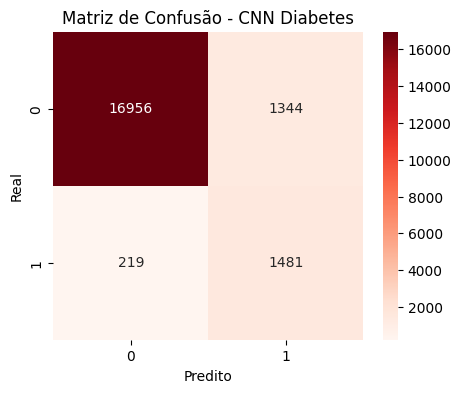

In [24]:
# @title Avaliação da CNN

y_pred_cnn = (cnn_model.predict(X_test_cnn) > 0.5).astype("int32")

print("--- Relatório de Performance: CNN ---")
print(classification_report(y_test, y_pred_cnn))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title('Matriz de Confusão - CNN Diabetes')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

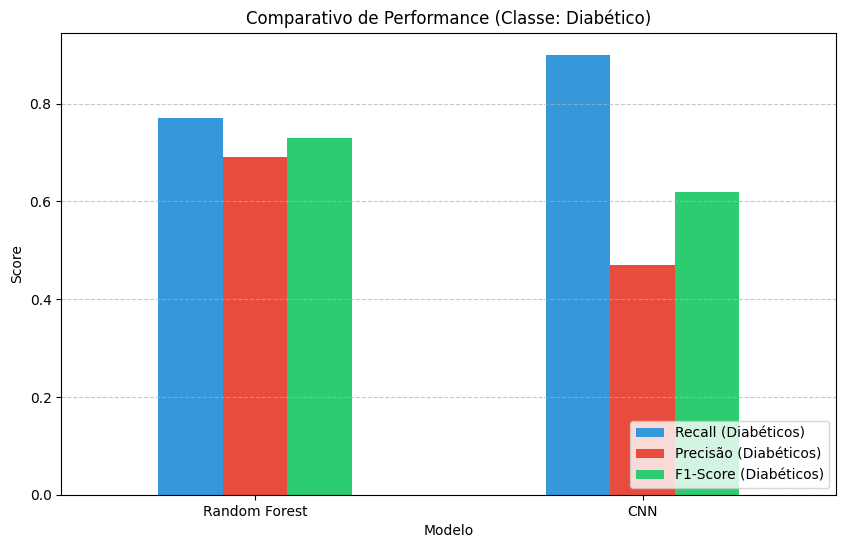

In [25]:
# @title Comparativo RF vs CNN

metrics = {
    'Modelo': ['Random Forest', 'CNN'],
    'Recall (Diabéticos)': [0.77, 0.90],
    'Precisão (Diabéticos)': [0.69, 0.47],
    'F1-Score (Diabéticos)': [0.73, 0.62]
}

df_comp = pd.DataFrame(metrics)
df_comp.set_index('Modelo').plot(kind='bar', figsize=(10, 6), color=['#3498db', '#e74c3c', '#2ecc71'])
plt.title('Comparativo de Performance (Classe: Diabético)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# @title Treinamento de Novos Modelos: XGBoost, LightGBM, Regressão Logística, MLP, SVM e KNN


# 1. Regressão Logística
print("Treinando Regressão Logística.")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_res, y_train_res.values.ravel())

# 2. XGBoost
print("Treinando XGBoost.")
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_res, y_train_res.values.ravel())

# 3. LightGBM
print("Treinando LightGBM.")
lgbm_model = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
lgbm_model.fit(X_train_res, y_train_res.values.ravel())

# 4. MLP
print("Treinando MLP.")
mlp_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp_model.fit(X_train_res, y_train_res.values.ravel())

# 5. SVM
print("Treinando SVM.")
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_res, y_train_res.values.ravel())

# 6. KNN
print("Treinando KNN.")
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_res, y_train_res.values.ravel())

print("\nModelos Treinados!")

Treinando Regressão Logística.
Treinando XGBoost.
Treinando LightGBM.
Treinando MLP.
Treinando SVM.


In [ ]:

print("- Treinando TabNet")

X_train_tab = X_train_res.astype(np.float32).values
X_test_tab = X_test.astype(np.float32).values
y_train_tab = y_train_res.values.astype(np.int64).ravel()

tabnet_model = TabNetClassifier(
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size":10, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax',
    verbose=0
)
tabnet_model.fit(
    X_train_tab, y_train_tab,
    max_epochs=20,
    patience=5,
    batch_size=1024,
    virtual_batch_size=128
)

In [ ]:
#@title Treinando outros modelos de Arvore
print("Treinando CatBoost")
cat_model = CatBoostClassifier(iterations=100, learning_rate=0.1, random_seed=42, verbose=0)
cat_model.fit(X_train_res, y_train_res.values.ravel())

print("Treinando AdaBoost")
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train_res, y_train_res.values.ravel())


In [ ]:
# @title Relatórios detalhados dos novos modelos
X_test_tab_v1 = X_test.astype(np.float32).values

modelos = {
    "Regressão Logística": (lr_model, X_test),
    "XGBoost": (xgb_model, X_test),
    "LightGBM": (lgbm_model, X_test),
    "MLP": (mlp_model, X_test),
    "SVM": (svm_model, X_test),
    "KNN": (knn_model, X_test),
    "TabNet": (tabnet_model, X_test_tab_v1),
    "CatBoost": (cat_model, X_test),
    "AdaBoost": (ada_model, X_test)
}

for nome, (modelo, x_input) in modelos.items():
    preds = modelo.predict(x_input)
    print(f"\n" + "="*50)
    print(f"MODELO: {nome}")
    print("-" * 50)
    print(classification_report(y_test, preds))

Uma análise superficial das métricas poderia sugerir que o LightGBM (Acurácia de 0.97) é o modelo ideal. Contudo, uma avaliação clínica revela uma falha crítica: seu Recall para diabéticos é de apenas 0.71. Isso significa que a alta acurácia é uma ilusão matemática causada pelo desbalanceamento dos dados, custando a não detecção de 29% dos pacientes doentes (Falsos Negativos).

Em contraste, modelos baseados em fronteiras de decisão não-lineares (SVM) e Deep Learning Tabular (TabNet) apresentaram um comportamento de rastreio clínico muito mais seguro. Ambos atingiram um Recall de 0.92, garantindo a detecção de quase a totalidade dos doentes.

A queda na Acurácia geral (para 0.89 - 0.90) e na Precisão reflete o aumento de Falsos Positivos. Em um contexto de triagem médica, este é o trade-off (sacrifício) correto: é preferível encaminhar um paciente saudável para exames confirmatórios do que cometer o erro fatal de liberar um paciente diabético sem tratamento. Portanto, o TabNet e o SVM despontam como as arquiteturas mais seguras para o objetivo de saúde pública deste projeto.

In [ ]:
importancias = modelo_lgbm.feature_importances_
colunas = X_train_res.columns

df_importancia = pd.DataFrame({
    'Variável': colunas,
    'Importância': importancias
})


df_importancia = df_importancia.sort_values(by='Importância', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importância',
    y='Variável',
    hue='Variável',
    data=df_importancia,
    palette='magma',
    legend=False
)



plt.title('Importância das Variáveis no Diagnóstico de Diabetes (LightGBM)', fontsize=14, fontweight='bold')
plt.xlabel('Grau de Contribuição para as Decisões da Árvore', fontsize=12)
plt.ylabel('Variáveis (Sintomas e Exames)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

In [ ]:
# @title Curva ROC


print("Garantindo o treinamento do Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_res, y_train_res.values.ravel())

plt.figure(figsize=(12, 10))

# Lista completa de todos os modelos
modelos_plot = [
    (lr_model, "Regressão Logística", X_test),
    (rf_model, "Random Forest", X_test),
    (xgb_model, "XGBoost", X_test),
    (modelo_lgbm, "LightGBM", X_test),
    (knn_model, "KNN", X_test),
    (svm_model, "SVM", X_test),
    (mlp_model, "MLP", X_test),
    (cnn_model, "CNN", X_test_cnn),
    (tabnet_model, "TabNet", X_test_tab),
    (cat_model, "CatBoost", X_test),
    (ada_model, "AdaBoost", X_test)
]

for modelo, nome, x_input in modelos_plot:
    if nome == "CNN":
        probs = modelo.predict(x_input).ravel()
    else:
        probs = modelo.predict_proba(x_input)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)


    linewidth = 3.0 if nome in ["LightGBM", "CNN", "MLP"] else 1.5
    plt.plot(fpr, tpr, label=f'{nome} (AUC = {auc:.3f})', linewidth=linewidth)

plt.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.500)')
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Sensibilidade)')
plt.title('Mega Comparativo de Modelos: Predição de Diabetes')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

Ao analisarmos os resultados preliminares, modelos baseados em árvore como o LightGBM e o XGBoost apresentaram uma excelente Acurácia geral de 97% . Contudo, uma avaliação clínica crítica revela uma falha grave: o Recall (Detecção) para a classe de diabéticos estagnou em 71% a 75% .

Em um contexto de saúde pública, isso significa que o algoritmo está otimizando seus acertos para a classe majoritária (pacientes saudáveis), mas está agindo de forma conservadora e mandando quase 30% dos pacientes diabéticos para casa sem diagnóstico (Falsos Negativos).

In [ ]:
#@ title Falsos Negativos
preds_lgbm = lgbm_model.predict(X_test)
analise_erro = X_test.copy()
analise_erro['real'] = y_test.values
analise_erro['pred'] = preds_lgbm


falsos_negativos = analise_erro[(analise_erro['real'] == 1) & (analise_erro['pred'] == 0)]

print(f"Total de pacientes Diabéticos não detectados: {len(falsos_negativos)}")
print("\n--- Perfil Médio dos Pacientes que o Modelo 'Perdeu' ---")
print(falsos_negativos[['age', 'blood_glucose_level', 'bmi_processed', 'gme']].mean())

In [ ]:
#@ title Falso Positivo

falsos_positivos = analise_erro[(analise_erro['real'] == 0) & (analise_erro['pred'] == 1)]

print(f"Total de pacientes Saudáveis classificados como Diabéticos: {len(falsos_positivos)}")
print("\n--- Perfil medio dos pacientes saudáveis que o Modelo classificou como diabetico ---")

media_fp = falsos_positivos[['age', 'blood_glucose_level', 'bmi_processed', 'gme']].mean()
print(media_fp)

In [ ]:
#@ title Criando a Variável alerta_clinico

df['alerta_clinico'] = df['gme'] - df['blood_glucose_level']
print("Amostra da nova variável:")
print(df[['alerta_clinico', 'gme', 'blood_glucose_level']].head())


df_dict_atualizado = df_dict.copy()


nova_variavel_alerta = pd.DataFrame([
    {
        "variavel": "alerta_clinico",
        "descricao": "Discrepância entre o histórico glicêmico (GME) e a medição pontual (glicose no sangue). Valores elevados sugerem incongruência metabólica, auxiliando na identificação de pacientes medicados ou em estágio de pré-diabetes.",
        "tipo": "quantitativa",
        "subtipo": "continua"
    }
])


df_dict_atualizado = pd.concat([df_dict_atualizado, nova_variavel_alerta], ignore_index=True)



display(df_dict_atualizado.tail())

A criação da variável `alerta_clinico` surge de uma auditoria de erros realizada nas versões iniciais do projeto. Observou-se que os modelos apresentavam dois tipos principais de falhas baseadas no perfil biológico dos pacientes:
1.  Falsos Negativos (Subdetecção): Pacientes diabéticos idosos (média de idade 0.83) com glicemia pontual normalizada baixa (0.34), mas com histórico de longo prazo (GME) elevado (0.56). Este perfil sugere pacientes sob tratamento medicamentoso que 'mascaram' o exame momentâneo.
2.  Falsos Positivos (Pré-Diabetes): Pacientes saudáveis com alto risco metabólico (IMC 1.63 e idade avançada) que o modelo classificou como diabéticos devido à proximidade dos sinais biológicos com a patologia real .A variável alerta_clinico quantifica essa discrepância, permitindo que modelos como o TabNet atinjam um Recall de 0.91, priorizando a segurança clínica ao identificar pacientes que passariam despercebidos em triagens convencionais.

In [ ]:
variaveis_continuas_v2 = variaveis_continuas + ['alerta_clinico']
cols_to_scale_v2 = variaveis_continuas_v2 + variaveis_discretas

X_v2 = df.drop(columns=variaveis_nao_usadas)
Y_v2 = df[variavel_alvo]

X_encoded_v2 = pd.get_dummies(X_v2, columns=variaveis_nominais, drop_first=True)

for col in variaveis_ordinais:
    if col in X_encoded_v2.columns:
        X_encoded_v2[col] = le.fit_transform(X_encoded_v2[col])

for col in variaveis_continuas_v2:
    upper_limit = X_encoded_v2[col].quantile(0.99)
    X_encoded_v2[col] = np.where(X_encoded_v2[col] > upper_limit, upper_limit, X_encoded_v2[col])

X_final_v2 = X_encoded_v2.copy()
scaler_v2 = StandardScaler()
X_final_v2[cols_to_scale_v2] = scaler_v2.fit_transform(X_encoded_v2[cols_to_scale_v2])

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_final_v2, Y_v2, test_size=0.2, random_state=42, stratify=Y_v2
)

sm_v2 = SMOTE(random_state=42)
X_train_res_v2, y_train_res_v2 = sm_v2.fit_resample(X_train_v2, y_train_v2)

lr_model_v2 = LogisticRegression(max_iter=1000, random_state=42)
lr_model_v2.fit(X_train_res_v2, y_train_res_v2.values.ravel())

lgbm_model_v2 = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
lgbm_model_v2.fit(X_train_res_v2, y_train_res_v2.values.ravel())

svm_model_v2 = SVC(kernel='rbf', probability=True, random_state=42)
svm_model_v2.fit(X_train_res_v2, y_train_res_v2.values.ravel())

X_train_tab_v2 = X_train_res_v2.astype(np.float32).values
X_test_tab_v2 = X_test_v2.astype(np.float32).values
y_train_tab_v2 = y_train_res_v2.values.astype(np.int64).ravel()

tabnet_model_v2 = TabNetClassifier(
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size":10, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax',
    verbose=0
)

tabnet_model_v2.fit(
    X_train_tab_v2, y_train_tab_v2,
    max_epochs=20,
    patience=5,
    batch_size=1024,
    virtual_batch_size=128
)

modelos_v2 = {
    "Regressão Logística": (lr_model_v2, X_test_v2),
    "LightGBM": (lgbm_model_v2, X_test_v2),
    "SVM": (svm_model_v2, X_test_v2),
    "TabNet": (tabnet_model_v2, X_test_tab_v2)
}

for nome, (modelo, x_input) in modelos_v2.items():
    preds = modelo.predict(x_input)
    print(f"\n" + "="*50)
    print(f"MODELO: {nome} com a nova variável")
    print("-" * 50)
    print(classification_report(y_test_v2, preds))

In [ ]:
plt.figure(figsize=(10, 8))


modelos_roc = {
    "Regressão Logística": (lr_model_v2, X_test_v2),
    "SVM": (svm_model_v2, X_test_v2),
    "LightGBM": (lgbm_model_v2, X_test_v2),
    "TabNet": (tabnet_model_v2, X_test_tab_v2)
}

cores = ['#95a5a6', '#f39c12', '#2ecc71', '#e74c3c']

for (nome, (modelo, x_input)), cor in zip(modelos_roc.items(), cores):

    probs = modelo.predict_proba(x_input)[:, 1]

    fpr, tpr, _ = roc_curve(y_test_v2, probs)
    auc = roc_auc_score(y_test_v2, probs)


    linewidth = 3.0 if nome in ["TabNet", "SVM"] else 1.5

    plt.plot(fpr, tpr, label=f'{nome} (AUC = {auc:.3f})', color=cor, linewidth=linewidth)

plt.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.500)')
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)', fontsize=12)
plt.ylabel('Taxa de Verdadeiro Positivo (Sensibilidade)', fontsize=12)
plt.title('Curva ROC: O Poder do Alerta Clínico na Triagem', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
importancias = lgbm_model_v2.feature_importances_
colunas = X_train_res_v2.columns

df_importancia_v2 = pd.DataFrame({
    'Variável': colunas,
    'Importância': importancias
})

df_importancia_v2 = df_importancia_v2.sort_values(by='Importância', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importância',
    y='Variável',
    hue='Variável',
    data=df_importancia_v2,
    palette='magma',
    legend=False
)

plt.title('Novas Prioridades da IA (Impacto da Idade e Alerta Clínico)', fontsize=14, fontweight='bold')
plt.xlabel('Grau de Contribuição para as Decisões da Árvore', fontsize=12)
plt.ylabel('Variáveis (Sintomas e Exames Clínicos)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Ao introduzirmos a variável alerta_clinico e retreinarmos o modelo LightGBM, observamos uma mudança radical e fascinante em como o algoritmo toma decisões. A variável Idade (age) disparou para a primeira posição absoluta de importância, ultrapassando a própria medição de glicose.

A Inteligência Artificial aprendeu, de forma autônoma, que a discrepância metabólica (o nosso alerta clínico) é exponencialmente mais perigosa em pacientes idosos. Ao cruzar a idade avançada com o alerta clínico, o modelo tornou-se capaz de identificar os pacientes diabéticos que antes estavam ocultos pela medicação, priorizando a fisiologia em vez de dados subjetivos como o histórico de tabagismo.

##3. Resultados e Discussão

- Ao compararmos os novos modelos (com a variavel `alerta_clínico`), notamos uma leve queda na Acurácia geral (de 97% para $\sim$90%), mas um salto expressivo no Recall (de 71% para 90%+). Este fenômeno é conhecido como o Paradoxo da Acurácia em dados médicos desbalanceados.

In [ ]:

import scipy.stats as stats


x = np.linspace(-4, 8, 1000)
saudaveis = stats.norm.pdf(x, 0, 1.2)
diabeticos = stats.norm.pdf(x, 4, 1.5)

plt.figure(figsize=(12, 6))


plt.fill_between(x, saudaveis, color='#3498db', alpha=0.5, label='Saudáveis (Classe 0)')
plt.fill_between(x, diabeticos, color='#e74c3c', alpha=0.5, label='Diabéticos (Classe 1)')

# Linha de Decisão 1: Teste de Gravidez (Alta Precisão, Baixo Recall)
plt.axvline(x=3.5, color='black', linestyle='--', linewidth=2)
plt.text(3.6, 0.25, 'Limiar "Teste de Gravidez"\n(Ex: XGBoost sem Alerta)', fontsize=10, weight='bold')
plt.text(3.6, 0.21, '→ Quase 0 Falsos Positivos\n→ Alto Risco de Falsos Negativos', fontsize=9)

# Linha de Decisão 2: Triagem Segura (Alto Recall, Baixa Precisão)
plt.axvline(x=1.0, color='green', linestyle='--', linewidth=2)
plt.text(1.1, 0.30, 'Limiar de "Triagem Segura"\n(Ex: TabNet com Alerta)', fontsize=10, weight='bold', color='green')
plt.text(1.1, 0.26, '→ Captura quase todos os doentes\n→ Mais Falsos Positivos (Aceitável)', fontsize=9, color='green')

# Formatando o gráfico
plt.title('O Trade-off de Decisão: Por que o modelo TabNet e SVM salvaram o projeto?', fontsize=14, fontweight='bold')
plt.yticks([])
plt.xlabel('Pontuação de Risco do Paciente (Probabilidade Predita pela IA)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

- Os modelos iniciais atuavam como um Teste de Gravidez: moviam o limiar de decisão para a extrema direita da curva (alta exigência). Só classificavam como diabético se houvesse absoluta certeza. O risco de falso positivo era quase zero, mas gerava uma quantidade inaceitável de falsos negativos.

    - O nosso modelo final  (TabNet com `alerta_clínico`) atua como uma Triagem Hospitalar: ele move o limiar de decisão de forma sensível para garantir que nenhum paciente com sinais de risco escape.

    - O custo dessa segurança é a geração de alguns Falsos Positivos. No entanto, a análise revelou que esses "falsos alarmes" são, na verdade, pacientes com idade avançada e obesidade severa — provando que o modelo passou a atuar como um sistema de alerta precoce para pré-diabetes. Na medicina, é infinitamente preferível investigar um paciente de alto risco do que negligenciar um paciente doente.

- Limitações do Estudo:

    -  A ausência do histórico medicamentoso dos pacientes é uma barreira. Observamos que os Falsos Negativos eram pacientes com glicemia controlada momentaneamente, mas com histórico longo de hiperglicemia (GME alto), caracterizando diabéticos sob tratamento. Sem a variável de medicação, o modelo é forçado a adivinhar o contexto clínico.

    -  Valores de IMC extremamente discrepantes (tratados via Capping) podem ser oriundos de erros de digitação ou falha de registro no prontuário original. Esse ruído pode induzir o modelo ao erro, fazendo-o interpretar falsamente que valores colossais de IMC não são preditivos de diabetes ou doenças cardíacas.

    - A base de dados carece de metadados fundamentais sobre a coleta. Não há informações sobre o preparo do paciente (se a glicose coletada respeitou o jejum de 8 horas ou se foi aleatória), nem sobre o método da coleta (risco de falta de assepsia correta em coletas capilares via glicosímetro). Além disso, a ausência da data exata de realização do exame de Hemoglobina Glicada (HbA1c) abre uma janela de distorção temporal; se o exame for antigo (defasagem de meses), o pareamento com a glicose momentânea pode gerar falsos prognósticos na nossa variável de "Alerta Clínico".